# TD N° 3 Machine Learning & Text Mining
## Techniques de régression (Régression logistique)

## Application de régression logistique

Considérons l'application de régression logistique suivante :

In [1]:
import numpy as np  # Chargement de numpy
import matplotlib.pyplot as plt  # import de Matplotlib
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [2]:
iris = datasets.load_iris()

print(iris.DESCR)

X = iris.data[:, :2]  
y = []
for e in iris.target:
    if e == 0:
        y += [0]
    else:
        y += [1]
y = np.array(y)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

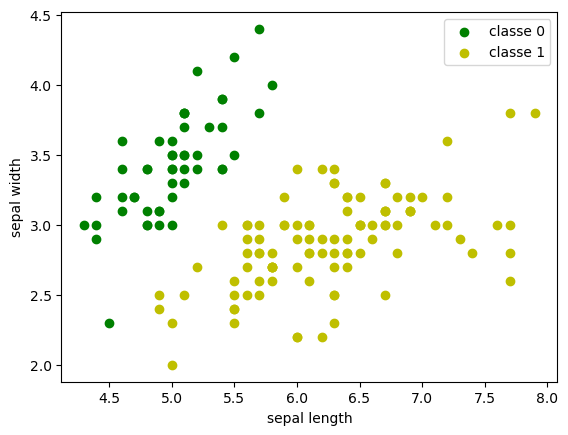

In [3]:
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='g')
# En Vert les fleurs ayant l'étiquette 0
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='y')
# en Jaune les fleurs ayant l'étiquette 1
plt.legend(labels=("classe 0", "classe 1"))
plt.xlabel("sepal length")
plt.ylabel("sepal width")
plt.show()

In [4]:
model = LogisticRegression(C=1e20)  # tester avec 0.01
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [5]:
model.fit(x_train, y_train)
score1 = model.score(x_test, y_test)
score2 = model.score(x_train, y_train)
print("score sur test-set =" + str(score1 * 100) + '%')
print("score sur train-set =" + str(score2 * 100) + '%')

score sur test-set =100.0%
score sur train-set =100.0%


In [6]:
theta0 = model.intercept_
theta1 = model.coef_[0][0]
theta2 = model.coef_[0][1]
Iries_To_Predict = [[5.5, 2.5], [7, 3], [3, 2], [5, 3]]
# demande de prédiction
print(model.predict(Iries_To_Predict))

[1 1 0 0]


In [7]:
score = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')

print(score)
print(score.mean())

[1.         1.         0.95833333 1.         1.        ]
0.9916666666666668


In [8]:
def fct_reg_logistic(x1, x2):
    z = (theta0) + theta1 * x1 + (theta2 * x2)
    return (z)

print([fct_reg_logistic(e[0], e[1]) for e in Iries_To_Predict])

[array([61.70357577]), array([144.63079789]), array([-108.07585411]), array([-29.07361765])]


---

## Travail à faire :

### Question 1
Consulter Iris dataset et identifier le type initial du problème ? régression ? classification multiclasse ou binaire ?

**Réponse:**
Le problème initial du dataset Iris est un problème de **classification multiclasse** avec 3 classes (setosa, versicolor, virginica). 

Cependant, dans ce notebook, le problème a été transformé en un problème de **classification binaire** :
- Classe 0 : setosa
- Classe 1 : versicolor et virginica

### Question 2
Quel est l'objectif des instructions ligne 8 à la ligne 13 ?

**Réponse:**

L'objectif de ces instructions (lignes 8 à 13) est de :

- **Ligne 8** : Sélectionner uniquement les 2 premières caractéristiques du dataset Iris (sepal length et sepal width) pour la variable X, afin de faciliter la visualisation en 2D.

- **Lignes 10-13** : Transformer le problème de classification multiclasse (3 classes) en un problème de classification binaire en créant un nouveau vecteur y où :
    - Les fleurs de classe 0 (setosa) gardent l'étiquette 0
    - Les fleurs de classes 1 et 2 (versicolor et virginica) reçoivent l'étiquette 1


### Question 3
Quel est l'intérêt de la fonction train_test_split? Chercher le rôle de ses paramètres : test_size? Random_state?

**Réponse:**
**Réponse:**

La fonction `train_test_split` permet de diviser le dataset en deux sous-ensembles : un ensemble d'entraînement et un ensemble de test. Ses principaux paramètres sont :

- **`test_size`** : Spécifie la proportion des données à utiliser pour le test (par exemple, 0.2 signifie 20% pour le test et 80% pour l'entraînement)
- **`random_state`** : Fixe une graine aléatoire pour assurer la reproductibilité ; utiliser la même valeur garantit la même division des données à chaque exécution du code

Cette division est essentielle pour évaluer la performance du modèle sur des données non vues, permettant ainsi d'éviter le surapprentissage en évaluant la capacité de généralisation du modèle.


### Question 4
À quoi correspond le score1 et le score2 et quelle est la différence entre les deux ?

**Réponse:**
- **score1** : Représente la **précision (accuracy) du modèle sur l'ensemble de test** (x_test, y_test). Il mesure la capacité du modèle à bien généraliser sur des données qu'il n'a jamais vues pendant l'entraînement.

- **score2** : Représente la **précision (accuracy) du modèle sur l'ensemble d'entraînement** (x_train, y_train). Il mesure la performance du modèle sur les données utilisées pour l'entraîner.

**Différence** : 
- Si score2 >> score1, cela indique un **surapprentissage (overfitting)** : le modèle mémorise les données d'entraînement mais généralise mal.
- Si score1 ≈ score2, cela indique une **bonne généralisation** du modèle.


### Question 5
Réexecuter l'expérimentation en variant test_size par 0.3, 0.4 et 0.5 et noter les scores correspondants ?

**Réponse:**


In [9]:
test_sizes = [0.3, 0.4, 0.5]

for test_size in test_sizes:
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=0)
    model.fit(x_train, y_train)
    score1 = model.score(x_test, y_test)
    score2 = model.score(x_train, y_train)
    print("test_size = " + str(test_size))
    print("score sur test-set =" + str(score1 * 100) + '%')
    print("score sur train-set =" + str(score2 * 100) + '%')

test_size = 0.3
score sur test-set =97.77777777777777%
score sur train-set =100.0%
test_size = 0.4
score sur test-set =98.33333333333333%
score sur train-set =100.0%
test_size = 0.5
score sur test-set =97.33333333333334%
score sur train-set =100.0%


### Question 6
Pourquoi la fonction cross_val_score est utilisé dans la ligne 35? Changer le paramètre cv et examiner les résultats obtenus ?

**Réponse:**

La fonction `cross_val_score` est utilisée pour effectuer une **validation croisée** du modèle. Elle permet d'évaluer la performance du modèle de manière plus robuste en divisant les données d'entraînement en `cv` sous-ensembles (folds), puis en entraînant et testant le modèle `cv` fois.

**Paramètre `cv`** : Détermine le nombre de sous-ensembles (folds) pour la validation croisée. Par exemple :
- `cv=5` : Les données sont divisées en 5 parties, le modèle est entraîné 5 fois (chaque fois avec 4/5 des données) et testé sur le 1/5 restant.

**Avantage** : Cela donne une estimation plus fiable de la performance du modèle en réduisant la variance liée à une seule division train/test.


In [10]:
# Expérimentation avec différentes valeurs de cv

cv_values = [3, 7, 10]

for cv in cv_values:
    score = cross_val_score(model, x_train, y_train, cv=cv, scoring='accuracy')
    print(f"cv = {cv}, scores = {score}, mean score = {score.mean()}")

cv = 3, scores = [0.96 1.   1.  ], mean score = 0.9866666666666667
cv = 7, scores = [1.         0.90909091 1.         1.         1.         1.
 1.        ], mean score = 0.987012987012987
cv = 10, scores = [1.    0.875 1.    1.    1.    1.    1.    1.    1.    1.   ], mean score = 0.9875
